In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.utils import resample 
from sklearn.preprocessing import OneHotEncoder

In [ ]:
Data = pd.read_csv("/home/omnix/Desktop/E-Commerce/E-commerce_EDA/Data/Raw_data.csv")
Data

In [ ]:
Data.info()

In [ ]:
Data.isnull().sum()

In [ ]:
Data['order_date']=Data['order_date'].fillna(Data['order_date'].mode()[0])
Data['customer_name'] =Data['customer_name'].fillna(Data['customer_name'].mode()[0])
Data['customer_email'] = Data['customer_email'].fillna(Data['customer_email'].mode()[0])
Data['customer_segment'] =Data['customer_segment'].fillna(Data['customer_segment'].mode()[0])
Data['quantity'] = Data['quantity'].fillna(Data['quantity'].mode()[0])
Data['unit_price'] = Data['unit_price'].fillna(Data['unit_price'].mode()[0])
Data['discount_percent'] = Data['discount_percent'].fillna(Data['discount_percent'].mean())
Data['shipping_region'] = Data['shipping_region'].fillna(Data['shipping_region'].mode()[0])
Data['shipping_cost'] = Data['shipping_cost'].fillna(Data['shipping_cost'].mean())
Data['shipping_method'] = Data['shipping_method'].fillna(Data['shipping_method'].mode()[0])
Data['payment_method'] = Data['payment_method'].fillna(Data['payment_method'].mode()[0])
Data['payment_status'] =Data['payment_status'].fillna(Data['payment_status'].mode()[0])
Data['rating'] = Data['rating'].fillna(Data['rating'].mean())
Data['review_text'] =Data['review_text'].fillna(Data['review_text'].mode()[0])
Data['return_flag'] = Data['return_flag'].fillna(Data['return_flag'].mode()[0])
Data['return_reason'] =Data['return_reason'].fillna(Data['return_reason'].mode()[0])

In [ ]:
Data.isnull().sum()

In [ ]:
Data

In [ ]:
# Data['order_id']=Data['order_id'].str.split('D').str[1].astype(int)
# Data['customer_id']=Data['customer_id'].str.split('T').str[1].astype(int)
Data['quantity'] = pd.to_numeric(Data['quantity'], errors='coerce').astype('Int64')
Data['unit_price'] = pd.to_numeric(Data['unit_price'],errors='coerce').astype(float)
Data['transaction_id'] = Data['transaction_id'].str.split('N').str[1].astype(int)


In [ ]:
Data.info()

In [ ]:
Data

In [ ]:
Data['order_date'] = pd.to_datetime(Data['order_date'], errors='coerce', 
                                     format='mixed', dayfirst=True)


Data['Year'] = Data['order_date'].dt.year.astype('Int64')
Data['Month'] = Data['order_date'].dt.month.astype('Int64')
Data['Day'] = Data['order_date'].dt.day.astype('Int64')


Data.drop('order_date', axis=1, inplace=True)  # Changed 'oredr_date' to 'order_date'

In [ ]:
Data

In [ ]:
Data.duplicated().sum()

In [ ]:
Data.drop_duplicates(inplace=True)

In [ ]:
Data.drop(Data[Data['quantity']<=0].index,inplace=True)

In [ ]:
Data.drop(Data[Data['unit_price']<=0].index,inplace=True)

In [ ]:
Data.drop(Data[Data['discount_percent']<=0].index,inplace=True)

In [ ]:
Data.drop(Data[Data['rating']<=0].index,inplace=True)

In [ ]:
Data['quantity'] = Data['quantity'].fillna(1)

In [ ]:
Data['unit_price']=Data['unit_price'].fillna(Data['unit_price'].mean())
Data['Year']=Data['Year'].fillna(Data['Year'].mode()[0])
Data['Month'] =Data['Month'].fillna(Data['Month'].mode()[0])
Data['Day'] = Data['Day'].fillna(Data['Day'].mode()[0])

In [ ]:
Data.isnull().sum()

In [ ]:
Data.drop('review_text',axis=1,inplace=True)

In [ ]:
Data.drop('')

In [ ]:
Data.describe()

In [ ]:
Data['total_revenue'] = (Data['quantity'] * Data['unit_price'] * (1 - Data['discount_percent'])) + Data['shipping_cost']

In [ ]:
Data.drop(Data[Data['total_revenue']<=0].index,inplace=True)

In [ ]:
Data

In [ ]:
# Quick fix for emails
Data['customer_email'] = Data['customer_email'].fillna('unknown@email.com')
Data['customer_email'] = Data['customer_email'].apply(lambda x: x if '@' in str(x) else f"{x}@email.com")
Data['customer_email'] = Data['customer_email'].str.replace('@@', '@')

# Quick fix for return reasons
Data.loc[Data['return_flag'] == False, 'return_reason'] = ''

In [ ]:
Data.drop('customer_email',axis=1,inplace=True)

In [ ]:
Data.drop('return_reason',axis=1,inplace=True)

In [ ]:
Data.drop('shipping_region',axis=1,inplace=True)

In [ ]:
Data.drop('order_id',axis=1,inplace=True) 

In [ ]:
Data

In [ ]:
Data['returned'] = Data['return_flag'].map({'False':0,"No":0,"N":0,"True":1,"Yes":1,"Y":1})

In [ ]:
Data['return_flag'].value_counts()

In [ ]:
Data

In [ ]:
Data.drop('return_flag',axis=1,inplace=True)

In [ ]:
Data

In [ ]:
# Optimized Column Order List

optimal_columns = [
    'customer_id',
    'transaction_id',
    'customer_name',
    'customer_segment',
    'product_name',
    'quantity',
    'unit_price',
    'discount_percent',
    'shipping_city',
    'shipping_method',
    'shipping_cost',
    'payment_method',
    'payment_status',
    'Year',
    'Month',
    'Day',
    'rating',
    'returned',
    'total_revenue'
]

Data=Data[optimal_columns]

In [ ]:
Data

In [ ]:
Data.to_csv("/home/omnix/Desktop/E-Commerce/E-commerce_EDA/Data/Cleaned.csv",index=False)

# Encoding the Data 


In [32]:
Data = pd.read_csv("/home/omnix/Desktop/E-Commerce/E-commerce_EDA/Data/Cleaned.csv")

In [33]:
Data.info()

<class 'pandas.DataFrame'>
RangeIndex: 17444 entries, 0 to 17443
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       17444 non-null  int64  
 1   transaction_id    17444 non-null  int64  
 2   customer_name     17444 non-null  str    
 3   customer_segment  17444 non-null  str    
 4   product_name      17444 non-null  str    
 5   quantity          17444 non-null  int64  
 6   unit_price        17444 non-null  float64
 7   discount_percent  17444 non-null  float64
 8   shipping_city     17444 non-null  str    
 9   shipping_method   17444 non-null  str    
 10  shipping_cost     17444 non-null  float64
 11  payment_method    17444 non-null  str    
 12  payment_status    17444 non-null  str    
 13  Year              17444 non-null  int64  
 14  Month             17444 non-null  int64  
 15  Day               17444 non-null  int64  
 16  rating            17444 non-null  float64
 17  retu

In [34]:
Data.describe()

,customer_id,transaction_id,quantity,unit_price,discount_percent,shipping_cost,Year,Month,Day,rating,returned,total_revenue
count,17444.000000,17444.000000,17444.000000,17444.000000,17444.000000,17444.000000,17444.000000,17444.000000,17444.000000,17444.000000,17444.000000,1.744400e+04
mean,1498.128182,54892.710903,4.427196,9451.411088,0.203252,49.354869,2023.509631,6.278033,14.459929,3.915658,0.090060,3.340370e+04
std,870.086549,26063.488168,3.088488,15339.631025,0.111818,29.237113,0.499922,3.533280,7.902051,1.165217,0.286275,6.992489e+04
min,1.000000,10001.000000,1.000000,170.080000,0.010000,-99.170000,2023.000000,1.000000,1.000000,1.000000,0.000000,5.508200e+01
25%,739.000000,32022.000000,1.000000,2012.010000,0.110000,24.950000,2023.000000,3.000000,8.000000,3.000000,0.000000,3.669364e+03
50%,1495.000000,54888.500000,4.000000,3680.930000,0.210000,49.399521,2024.000000,6.000000,14.000000,4.000000,0.000000,1.129948e+04
75%,2256.000000,77328.500000,7.000000,11272.380000,0.300000,74.042500,2024.000000,9.000000,21.000000,5.000000,0.000000,3.226603e+04
max,3000.000000,99998.000000,10.000000,275000.000000,0.400000,100.000000,2024.000000,12.000000,28.000000,5.000000,1.000000,2.128551e+06


In [35]:
Data


,customer_id,transaction_id,customer_name,customer_segment,product_name,quantity,unit_price,discount_percent,shipping_city,shipping_method,shipping_cost,payment_method,payment_status,Year,Month,Day,rating,returned,total_revenue
0,544,27014,Alok Yadav,Silver,Monitor,2,13834.280000,0.240000,Delhi,Express,96.20,Debit Card,Paid,2023,11,16,2.0,0,21124.305600
1,2713,17450,Priya Verma,Standard,Printer,2,12684.380000,0.310000,Hyderabad,Same Day,48.06,COD,Pending,2024,7,12,2.0,0,17552.504400
2,2105,71839,Alok Sharma,Standard,Desk Lamp,1,1557.140000,0.390000,Mumbai,Same Day,96.92,UPI,Paid,2024,6,25,5.0,0,1046.775400
3,2110,73153,Ritu Joshi,Standard,Smart Watch,1,8478.670000,0.130000,Pune,Standard,62.92,Debit Card,Paid,2024,6,26,5.0,1,7439.362900
4,2400,69826,Amit Verma,Standard,Gaming Chair,2,11976.960000,0.190000,Pune,Standard,97.56,UPI,Paid,2023,6,12,4.0,1,19500.235200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17439,252,13843,Sunil Verma,New,Tablet,8,27304.630000,0.240000,Mumbai,Standard,3.13,UPI,Paid,2023,4,5,4.0,0,166015.280400
17440,2059,54224,Neha Malhotra,Silver,Router,1,3348.360000,0.070000,Hyderabad,Express,80.69,Credit Card,Failed,2023,9,20,4.0,0,3194.664800
17441,1260,27200,Amit Yadav,New,Desk Lamp,10,1620.800000,0.226173,Jaipur,Express,66.51,Credit Card,Paid,2024,1,25,1.0,0,12608.698060
17442,2705,12729,Pooja Yadav,Standard,Headphones,1,9447.351522,0.170000,Mumbai,Express,76.95,Debit Card,Paid,2024,12,4,5.0,0,7918.251763


In [36]:
Data.drop("customer_name",axis=1,inplace=True)

In [37]:
Encoder=OneHotEncoder(sparse_output=False)
Encoded_customer_segment = Encoder.fit_transform(Data[['customer_segment']])
Df = pd.DataFrame(Encoded_customer_segment,columns=Encoder.get_feature_names_out())

Data.drop('customer_segment',axis=1,inplace=True)
Data = pd.concat([Data,Df],axis=1)

In [38]:
encoder= OneHotEncoder(sparse_output=False)
encoded_data = encoder.fit_transform(Data[['product_name']])
df = pd.DataFrame(encoded_data,columns=encoder.get_feature_names_out())

Data.drop('product_name',axis=1,inplace=True)
Data = pd.concat([Data,df],axis=1)


In [39]:
# Remove Failed rows and reset index
Data = Data[Data['payment_status'] != 'Failed'].reset_index(drop=True)

# Encode
encoder = OneHotEncoder(sparse_output=False)
encoded_payment_status = encoder.fit_transform(Data[['payment_status']])
encoded_df = pd.DataFrame(encoded_payment_status, columns=encoder.get_feature_names_out())

# Drop original column
Data = Data.drop('payment_status', axis=1)

# Concatenate (indices now align)
Data = pd.concat([Data, encoded_df], axis=1)

# No NaN values should appear
print(f"Final shape: {Data.shape}")
print(f"NaN count: {Data.isnull().sum().sum()}")

Final shape: (16419, 41)
NaN count: 0


In [40]:
Data

,customer_id,transaction_id,quantity,unit_price,discount_percent,shipping_city,shipping_method,shipping_cost,payment_method,Year,...,product_name_Router,product_name_Smart Watch,product_name_Speakers,product_name_Tablet,product_name_USB Cable,product_name_Webcam,payment_status_Chargeback,payment_status_Paid,payment_status_Pending,payment_status_Refunded
0,544,27014,2,13834.280000,0.240000,Delhi,Express,96.20,Debit Card,2023,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,2713,17450,2,12684.380000,0.310000,Hyderabad,Same Day,48.06,COD,2024,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,2105,71839,1,1557.140000,0.390000,Mumbai,Same Day,96.92,UPI,2024,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,2110,73153,1,8478.670000,0.130000,Pune,Standard,62.92,Debit Card,2024,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,2400,69826,2,11976.960000,0.190000,Pune,Standard,97.56,UPI,2023,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16414,2459,68369,2,25481.500000,0.010000,Pune,Standard,62.55,Credit Card,2024,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
16415,252,13843,8,27304.630000,0.240000,Mumbai,Standard,3.13,UPI,2023,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
16416,1260,27200,10,1620.800000,0.226173,Jaipur,Express,66.51,Credit Card,2024,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
16417,2705,12729,1,9447.351522,0.170000,Mumbai,Express,76.95,Debit Card,2024,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [41]:
Data.info()

<class 'pandas.DataFrame'>
RangeIndex: 16419 entries, 0 to 16418
Data columns (total 41 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                16419 non-null  int64  
 1   transaction_id             16419 non-null  int64  
 2   quantity                   16419 non-null  int64  
 3   unit_price                 16419 non-null  float64
 4   discount_percent           16419 non-null  float64
 5   shipping_city              16419 non-null  str    
 6   shipping_method            16419 non-null  str    
 7   shipping_cost              16419 non-null  float64
 8   payment_method             16419 non-null  str    
 9   Year                       16419 non-null  int64  
 10  Month                      16419 non-null  int64  
 11  Day                        16419 non-null  int64  
 12  rating                     16419 non-null  float64
 13  returned                   16419 non-null  int64  
 14  t

In [ ]:
City_Encoder = OneHotEncoder(sparse_output=False)


In [43]:
Data.drop('shipping_city',axis=1,inplace=True)

In [46]:
Data.drop('shipping_method',axis=1,inplace=True)


In [48]:
Data['payment_method'].value_counts()

payment_method
Credit Card    5206
Debit Card     4125
UPI            3227
NetBanking     1639
COD            1335
Wallet          887
Name: count, dtype: int64

In [49]:
Data.drop('payment_method',axis=1,inplace=True)

In [51]:
Data.info()

<class 'pandas.DataFrame'>
RangeIndex: 16419 entries, 0 to 16418
Data columns (total 38 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                16419 non-null  int64  
 1   transaction_id             16419 non-null  int64  
 2   quantity                   16419 non-null  int64  
 3   unit_price                 16419 non-null  float64
 4   discount_percent           16419 non-null  float64
 5   shipping_cost              16419 non-null  float64
 6   Year                       16419 non-null  int64  
 7   Month                      16419 non-null  int64  
 8   Day                        16419 non-null  int64  
 9   rating                     16419 non-null  float64
 10  returned                   16419 non-null  int64  
 11  total_revenue              16419 non-null  float64
 12  customer_segment_Gold      16419 non-null  float64
 13  customer_segment_New       16419 non-null  float64
 14  c

<Axes: >

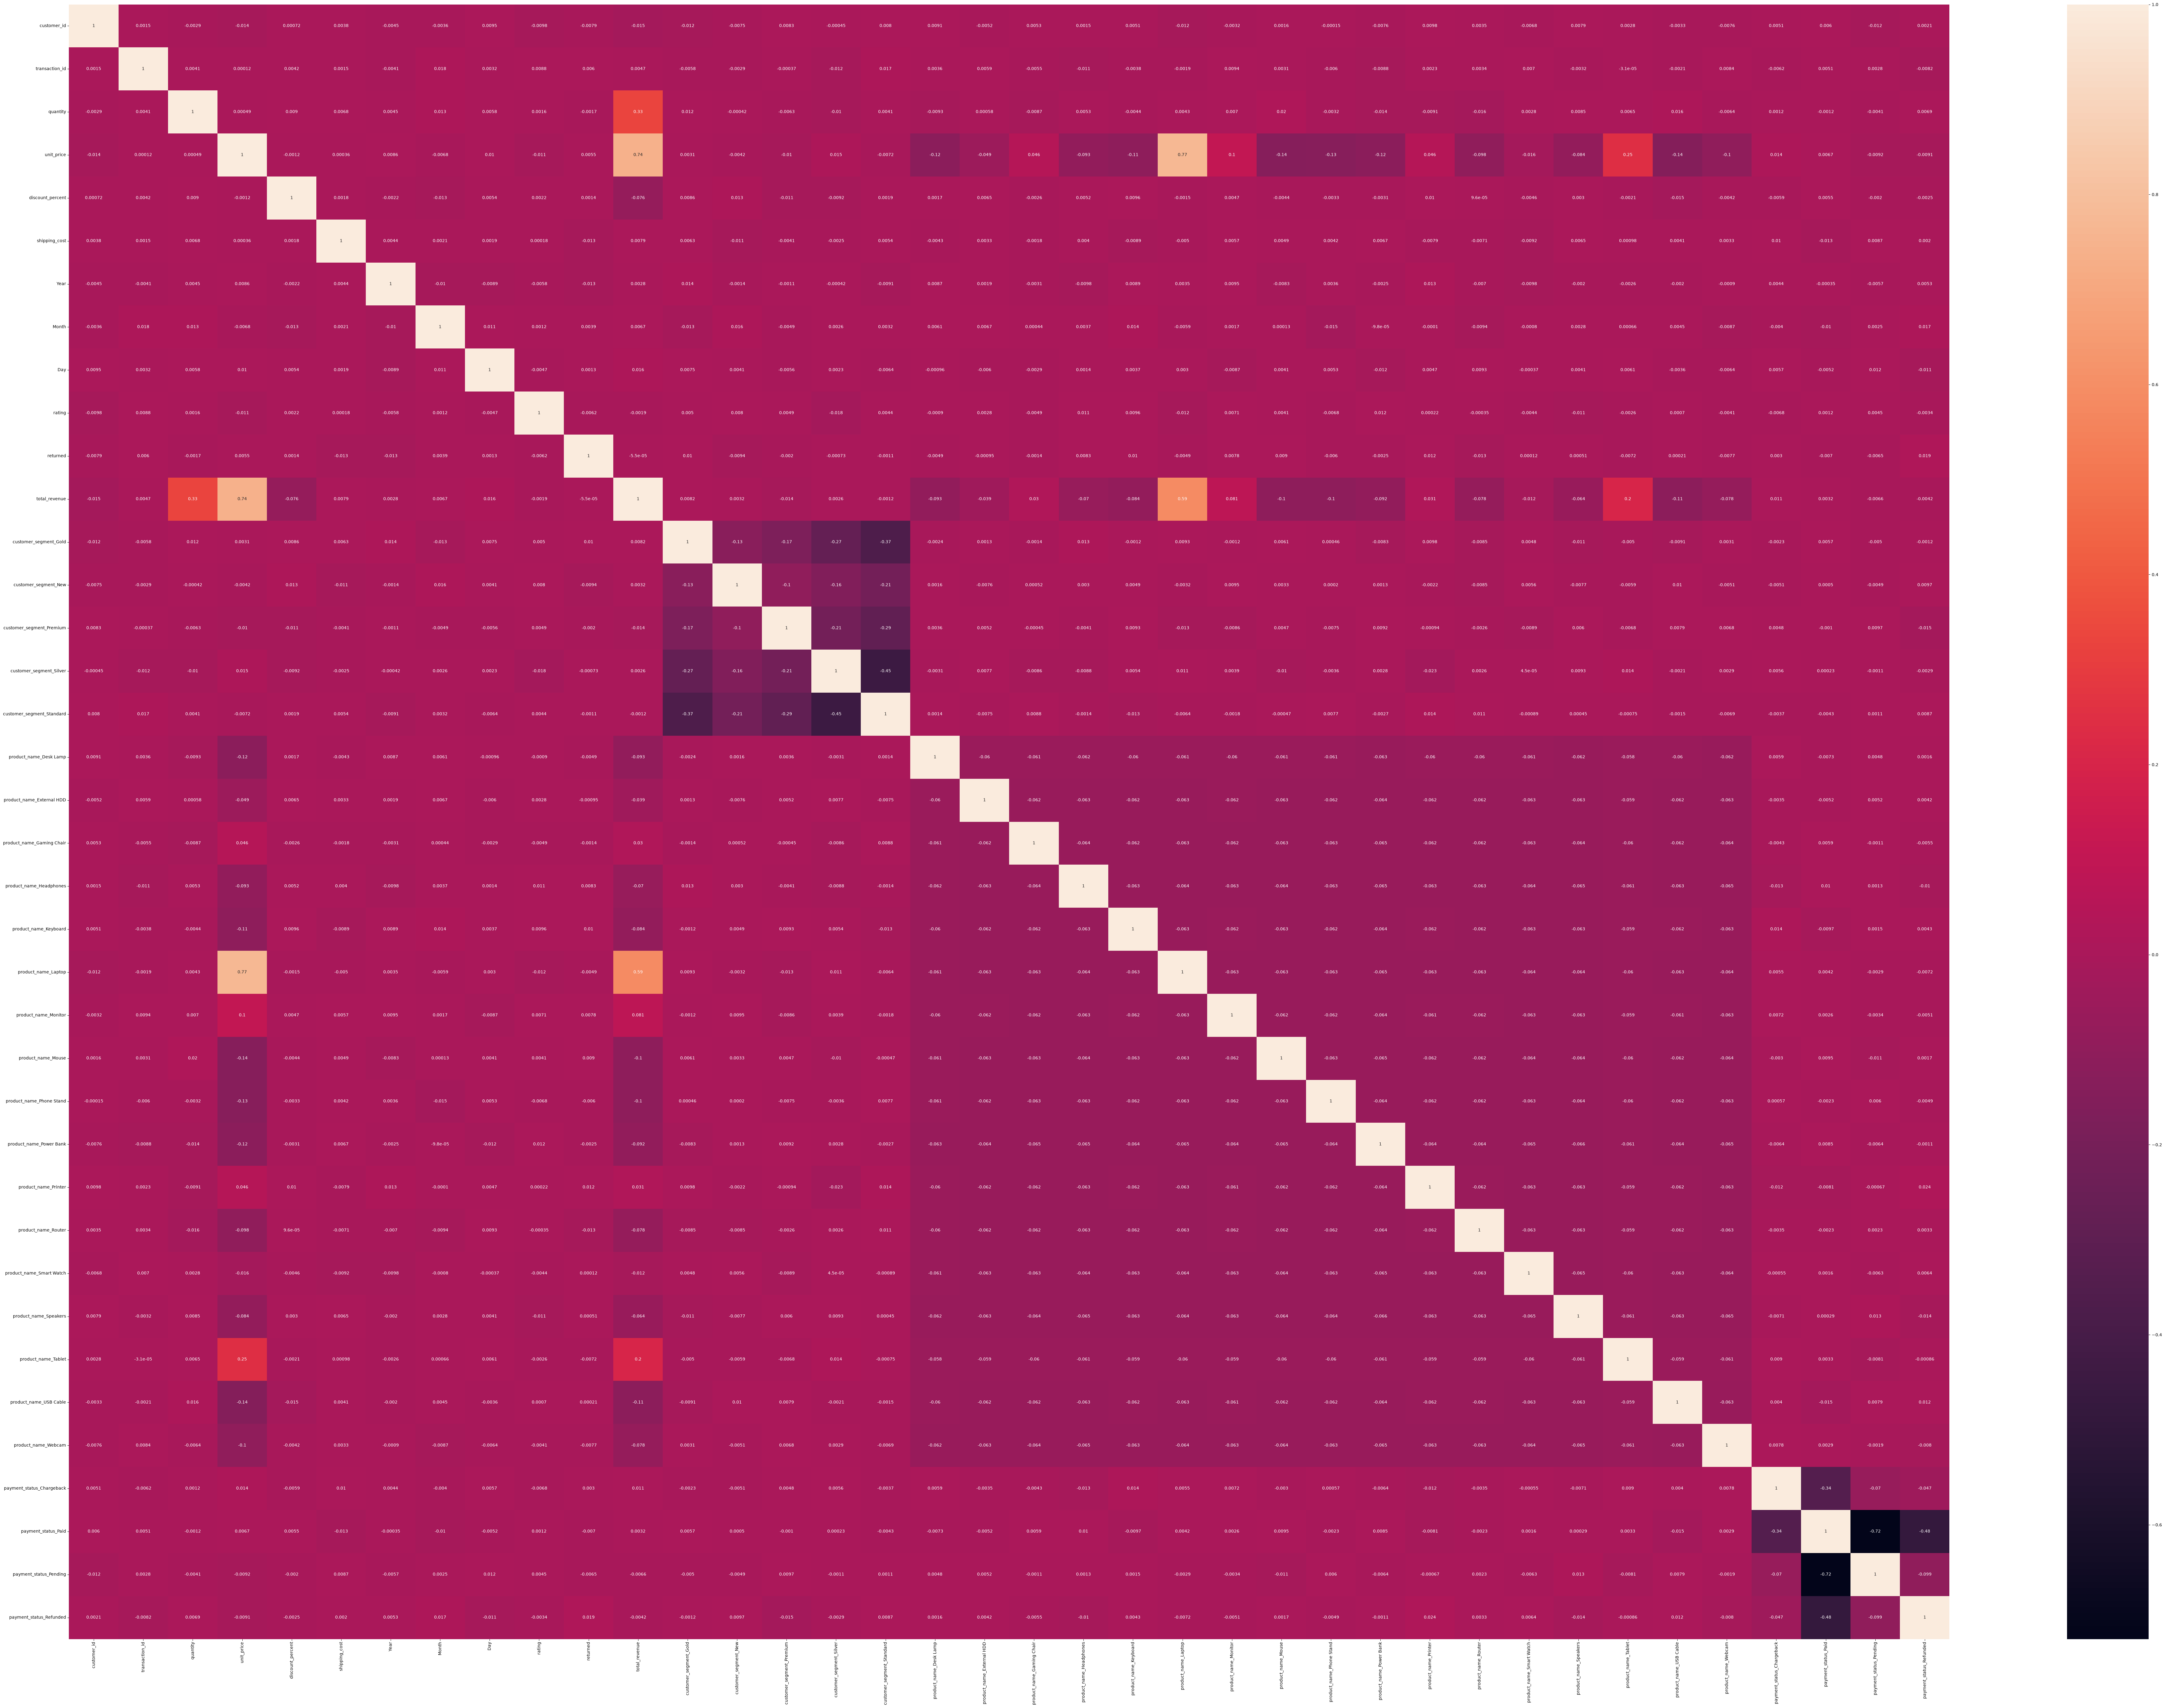

In [55]:
plt.figure(figsize=(100,70))
sns.heatmap(Data.corr(),annot=True)

In [57]:
Data.drop('customer_id',axis=1,inplace=True)
Data.drop('transaction_id',axis=1,inplace=True)
Data.drop('Day',axis=1,inplace=True)
Data.drop('Month',axis=1,inplace=True)
Data.drop(Data[Data['payment_status_Refunded']==1].index,inplace=True)

In [58]:
Data['payment_status_Refunded'].value_counts()

payment_status_Refunded
0.0    15404
Name: count, dtype: int64

In [59]:
Data.drop('payment_status_Refunded',axis=1,inplace=True)

In [63]:
Data.drop(Data[Data['returned']==1].index,inplace=True)

In [65]:
Data.drop('returned',axis=1,inplace=True)

<Axes: >

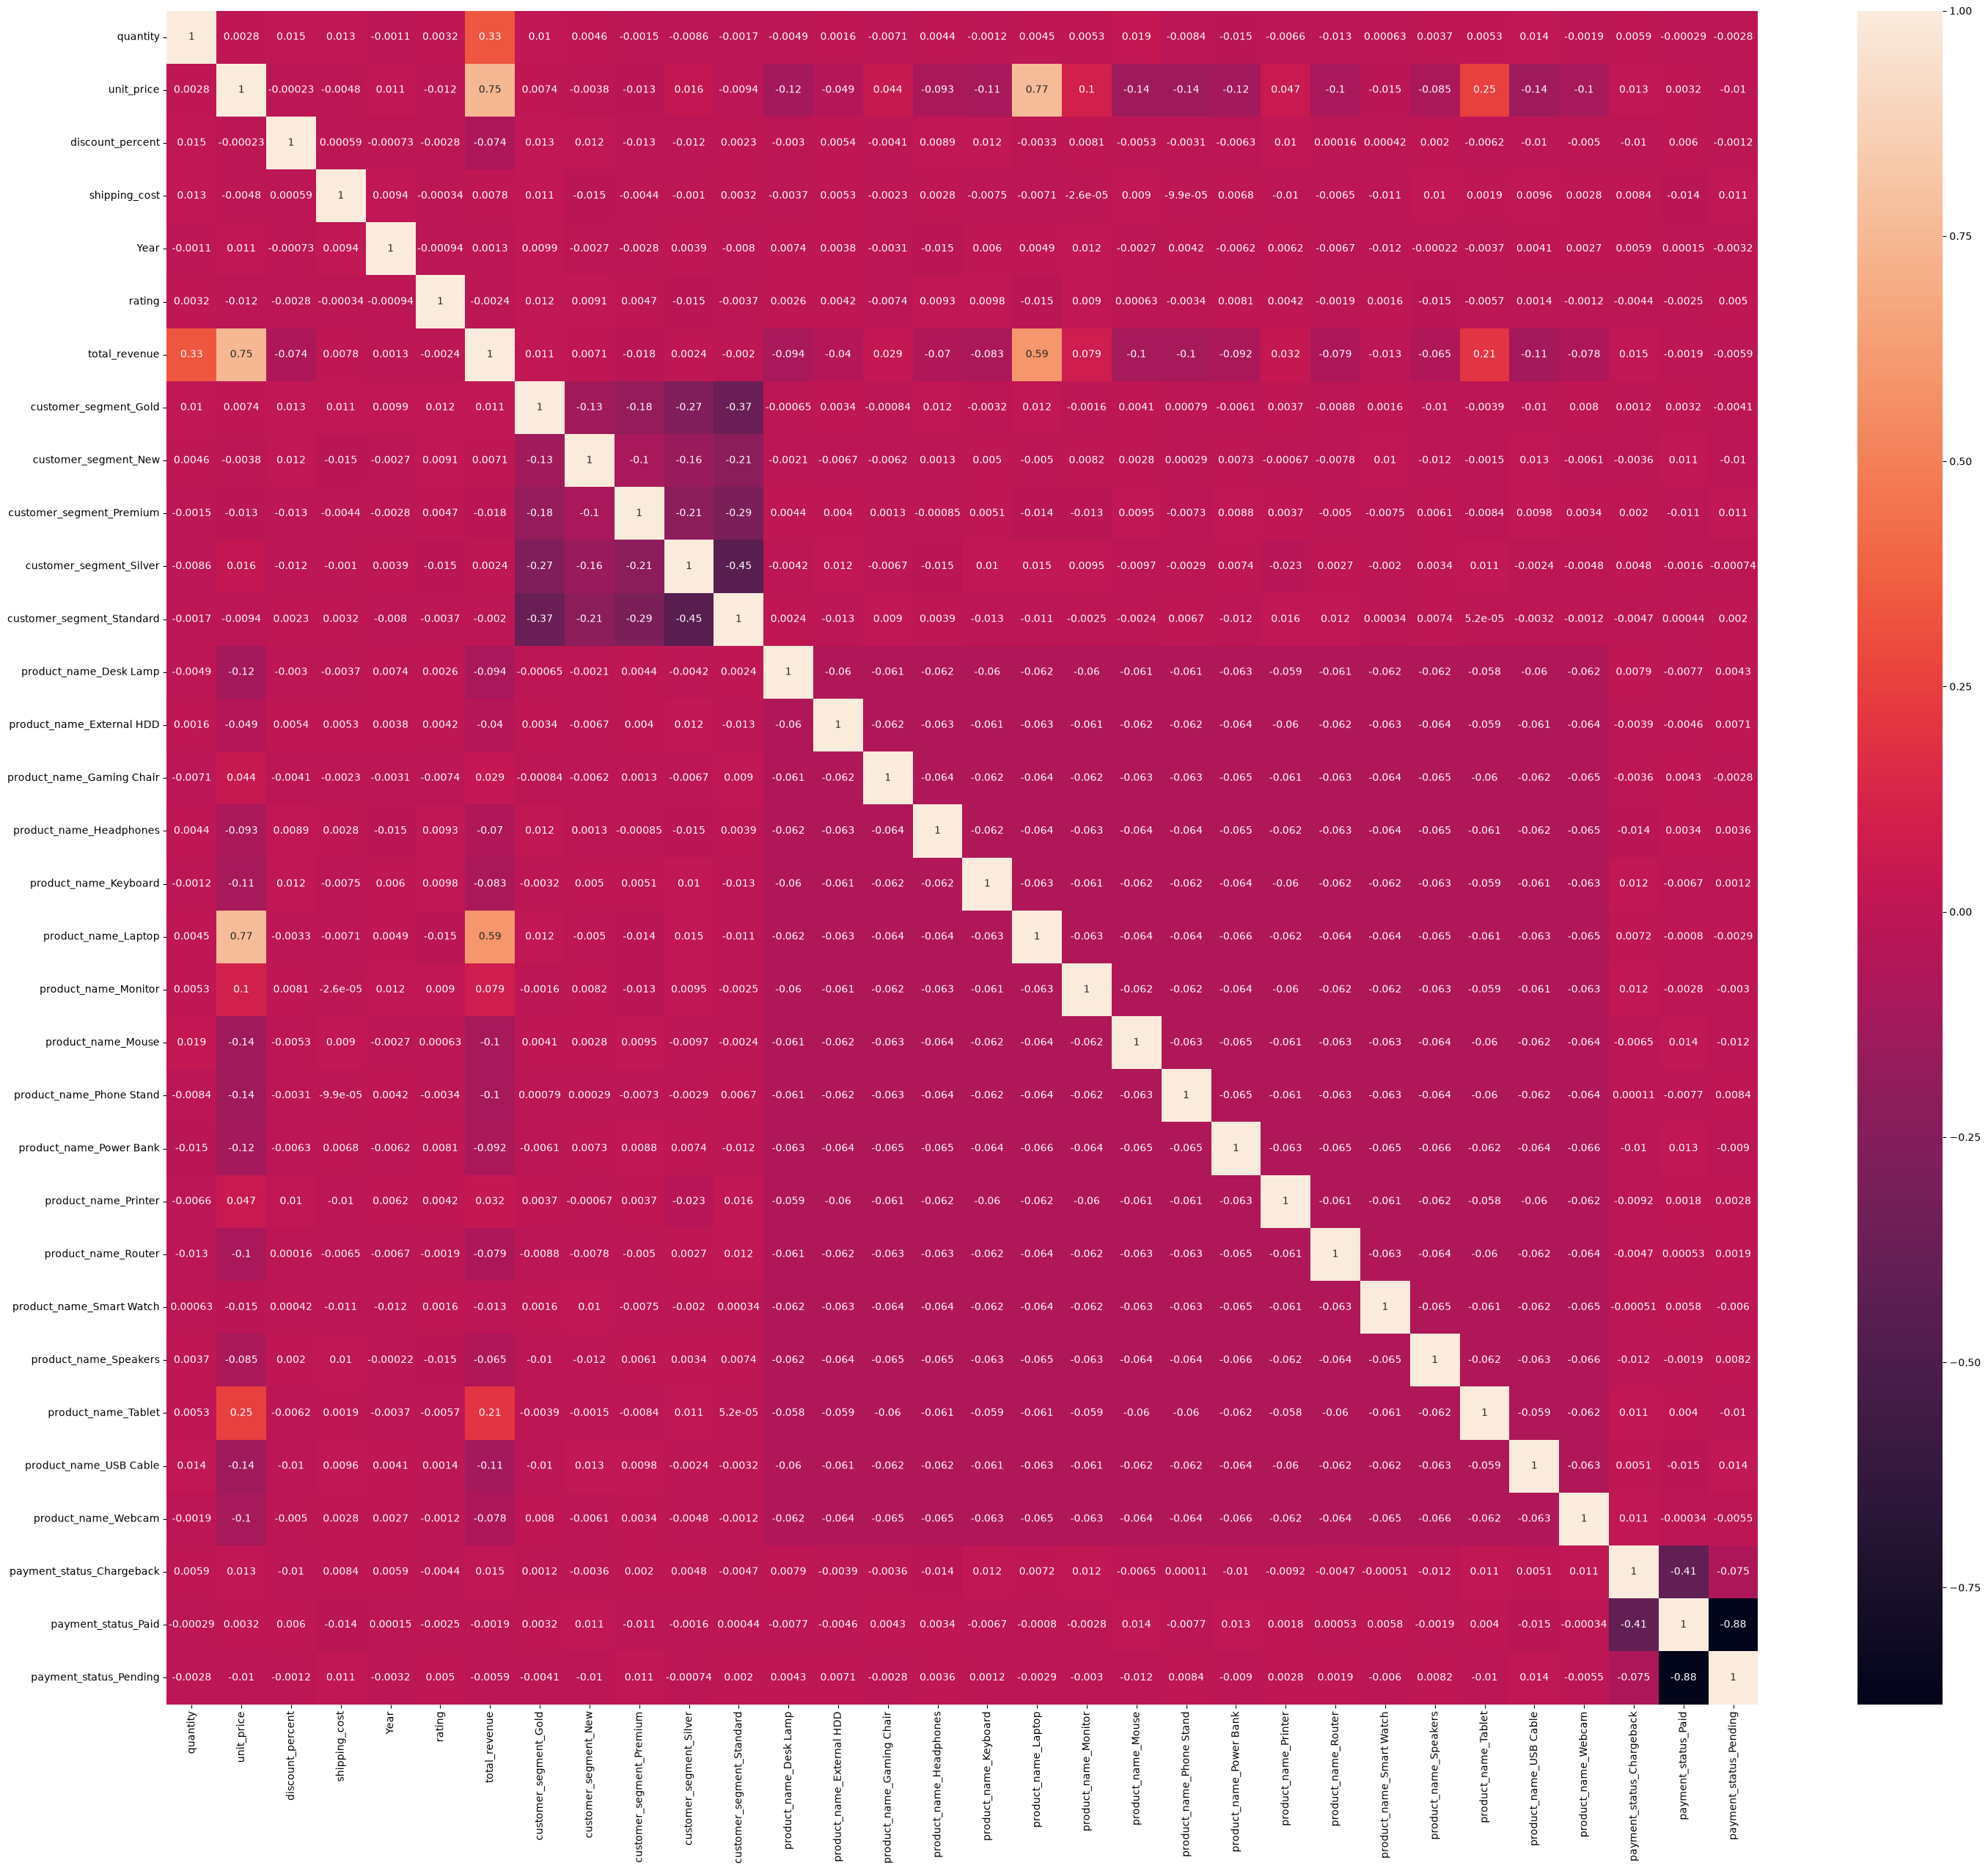

In [70]:
plt.figure(figsize=(35,30))
sns.heatmap(Data.corr(),annot=True)

In [71]:
Data.drop('payment_status_Paid',axis=1,inplace=True)
Data.drop('payment_status_Pending',axis=1,inplace=True)

In [73]:
Data.drop('payment_status_Chargeback',axis=1,inplace=True)

In [75]:
Data.drop(['customer_segment_New','product_name_USB Cable'],axis=1,inplace=True)


In [76]:
Data

,quantity,unit_price,discount_percent,shipping_cost,Year,rating,total_revenue,customer_segment_Gold,customer_segment_Premium,customer_segment_Silver,...,product_name_Monitor,product_name_Mouse,product_name_Phone Stand,product_name_Power Bank,product_name_Printer,product_name_Router,product_name_Smart Watch,product_name_Speakers,product_name_Tablet,product_name_Webcam
0,2,13834.280000,0.240000,96.20,2023,2.0,21124.305600,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,12684.380000,0.310000,48.06,2024,2.0,17552.504400,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,1,1557.140000,0.390000,96.92,2024,5.0,1046.775400,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,2,5265.590000,0.360000,8.27,2023,1.0,6748.225200,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,9,48124.580000,0.340000,34.94,2024,5.0,285894.945200,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16413,1,11725.630000,0.130000,63.26,2024,2.0,10264.558100,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
16415,8,27304.630000,0.240000,3.13,2023,4.0,166015.280400,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
16416,10,1620.800000,0.226173,66.51,2024,1.0,12608.698060,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
16417,1,9447.351522,0.170000,76.95,2024,5.0,7918.251763,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [77]:
Data.info()

<class 'pandas.DataFrame'>
Index: 14023 entries, 0 to 16418
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   quantity                   14023 non-null  int64  
 1   unit_price                 14023 non-null  float64
 2   discount_percent           14023 non-null  float64
 3   shipping_cost              14023 non-null  float64
 4   Year                       14023 non-null  int64  
 5   rating                     14023 non-null  float64
 6   total_revenue              14023 non-null  float64
 7   customer_segment_Gold      14023 non-null  float64
 8   customer_segment_Premium   14023 non-null  float64
 9   customer_segment_Silver    14023 non-null  float64
 10  customer_segment_Standard  14023 non-null  float64
 11  product_name_Desk Lamp     14023 non-null  float64
 12  product_name_External HDD  14023 non-null  float64
 13  product_name_Gaming Chair  14023 non-null  float64
 14  produc

In [78]:
Data.drop(['customer_segment_Silver','customer_segment_Standard'],axis=1,inplace=True)

In [79]:
Data

,quantity,unit_price,discount_percent,shipping_cost,Year,rating,total_revenue,customer_segment_Gold,customer_segment_Premium,product_name_Desk Lamp,...,product_name_Monitor,product_name_Mouse,product_name_Phone Stand,product_name_Power Bank,product_name_Printer,product_name_Router,product_name_Smart Watch,product_name_Speakers,product_name_Tablet,product_name_Webcam
0,2,13834.280000,0.240000,96.20,2023,2.0,21124.305600,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,12684.380000,0.310000,48.06,2024,2.0,17552.504400,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,1,1557.140000,0.390000,96.92,2024,5.0,1046.775400,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,2,5265.590000,0.360000,8.27,2023,1.0,6748.225200,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,9,48124.580000,0.340000,34.94,2024,5.0,285894.945200,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16413,1,11725.630000,0.130000,63.26,2024,2.0,10264.558100,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
16415,8,27304.630000,0.240000,3.13,2023,4.0,166015.280400,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
16416,10,1620.800000,0.226173,66.51,2024,1.0,12608.698060,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
16417,1,9447.351522,0.170000,76.95,2024,5.0,7918.251763,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [83]:
Data.drop(Data[Data['product_name_Webcam']==1].index,inplace=True)

In [86]:
Data.drop('product_name_Webcam',axis=1,inplace=True)

In [88]:
Data['product_name_Desk Lamp'].value_counts()

product_name_Desk Lamp
0.0    12372
1.0      785
Name: count, dtype: int64

In [89]:
Data.drop(Data[Data['product_name_Desk Lamp']==1].index,inplace=True)
Data.drop('product_name_Desk Lamp',axis=1,inplace=True)

In [90]:
Data

,quantity,unit_price,discount_percent,shipping_cost,Year,rating,total_revenue,customer_segment_Gold,customer_segment_Premium,product_name_External HDD,...,product_name_Laptop,product_name_Monitor,product_name_Mouse,product_name_Phone Stand,product_name_Power Bank,product_name_Printer,product_name_Router,product_name_Smart Watch,product_name_Speakers,product_name_Tablet
0,2,13834.280000,0.240000,96.20,2023,2.0,21124.305600,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,12684.380000,0.310000,48.06,2024,2.0,17552.504400,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
5,2,5265.590000,0.360000,8.27,2023,1.0,6748.225200,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,9,48124.580000,0.340000,34.94,2024,5.0,285894.945200,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,1,11186.490000,0.070000,50.32,2023,3.0,10453.755700,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16412,7,2870.710000,0.226173,81.52,2023,3.0,15631.550405,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
16413,1,11725.630000,0.130000,63.26,2024,2.0,10264.558100,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
16415,8,27304.630000,0.240000,3.13,2023,4.0,166015.280400,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
16417,1,9447.351522,0.170000,76.95,2024,5.0,7918.251763,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [91]:
Data['customer_segment_Gold'].value_counts()

customer_segment_Gold
0.0    10131
1.0     2241
Name: count, dtype: int64

In [92]:
Data['customer_segment_Premium'].value_counts()

customer_segment_Premium
0.0    10877
1.0     1495
Name: count, dtype: int64

In [93]:
Data['product_name_External HDD'].value_counts()

product_name_External HDD
0.0    11560
1.0      812
Name: count, dtype: int64

In [94]:
Data['product_name_Laptop'].value_counts()

product_name_Laptop
0.0    11521
1.0      851
Name: count, dtype: int64

In [95]:
Data['product_name_Monitor'].value_counts()

product_name_Monitor
0.0    11564
1.0      808
Name: count, dtype: int64

In [96]:
Data

,quantity,unit_price,discount_percent,shipping_cost,Year,rating,total_revenue,customer_segment_Gold,customer_segment_Premium,product_name_External HDD,...,product_name_Laptop,product_name_Monitor,product_name_Mouse,product_name_Phone Stand,product_name_Power Bank,product_name_Printer,product_name_Router,product_name_Smart Watch,product_name_Speakers,product_name_Tablet
0,2,13834.280000,0.240000,96.20,2023,2.0,21124.305600,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,12684.380000,0.310000,48.06,2024,2.0,17552.504400,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
5,2,5265.590000,0.360000,8.27,2023,1.0,6748.225200,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,9,48124.580000,0.340000,34.94,2024,5.0,285894.945200,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,1,11186.490000,0.070000,50.32,2023,3.0,10453.755700,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16412,7,2870.710000,0.226173,81.52,2023,3.0,15631.550405,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
16413,1,11725.630000,0.130000,63.26,2024,2.0,10264.558100,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
16415,8,27304.630000,0.240000,3.13,2023,4.0,166015.280400,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
16417,1,9447.351522,0.170000,76.95,2024,5.0,7918.251763,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [102]:
Data['subtotal'] = Data['quantity'] * Data['unit_price']
Data['discount_amount'] = Data['subtotal'] * Data['discount_percent']
Data['net_amount'] = Data['subtotal'] - Data['discount_amount']
Data['Revenue'] = Data['net_amount'] + Data['shipping_cost']

# Verify (should match total_revenue)
verification = (Data['calculated_total'] - Data['total_revenue']).abs().sum()
print(f"Verification error: {verification:.2f} (should be 0)")

Verification error: 0.00 (should be 0)


In [103]:
Data

,quantity,unit_price,discount_percent,shipping_cost,Year,rating,total_revenue,customer_segment_Gold,customer_segment_Premium,product_name_External HDD,...,product_name_Printer,product_name_Router,product_name_Smart Watch,product_name_Speakers,product_name_Tablet,subtotal,discount_amount,net_amount,calculated_total,Revenue
0,2,13834.280000,0.240000,96.20,2023,2.0,21124.305600,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,27668.560000,6640.454400,21028.105600,21124.305600,21124.305600
1,2,12684.380000,0.310000,48.06,2024,2.0,17552.504400,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,25368.760000,7864.315600,17504.444400,17552.504400,17552.504400
5,2,5265.590000,0.360000,8.27,2023,1.0,6748.225200,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,10531.180000,3791.224800,6739.955200,6748.225200,6748.225200
6,9,48124.580000,0.340000,34.94,2024,5.0,285894.945200,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,433121.220000,147261.214800,285860.005200,285894.945200,285894.945200
7,1,11186.490000,0.070000,50.32,2023,3.0,10453.755700,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,11186.490000,783.054300,10403.435700,10453.755700,10453.755700
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16412,7,2870.710000,0.226173,81.52,2023,3.0,15631.550405,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,20094.970000,4544.939595,15550.030405,15631.550405,15631.550405
16413,1,11725.630000,0.130000,63.26,2024,2.0,10264.558100,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11725.630000,1524.331900,10201.298100,10264.558100,10264.558100
16415,8,27304.630000,0.240000,3.13,2023,4.0,166015.280400,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,218437.040000,52424.889600,166012.150400,166015.280400,166015.280400
16417,1,9447.351522,0.170000,76.95,2024,5.0,7918.251763,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,9447.351522,1606.049759,7841.301763,7918.251763,7918.251763


In [104]:
Data.drop('total_revenue',axis=1,inplace=True)
Data.drop('calculated_total',axis=1,inplace=True)

In [106]:
Data.drop('net_amount',axis=1,inplace=True)

In [107]:
Data

,quantity,unit_price,discount_percent,shipping_cost,Year,rating,customer_segment_Gold,customer_segment_Premium,product_name_External HDD,product_name_Gaming Chair,...,product_name_Phone Stand,product_name_Power Bank,product_name_Printer,product_name_Router,product_name_Smart Watch,product_name_Speakers,product_name_Tablet,subtotal,discount_amount,Revenue
0,2,13834.280000,0.240000,96.20,2023,2.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,27668.560000,6640.454400,21124.305600
1,2,12684.380000,0.310000,48.06,2024,2.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,25368.760000,7864.315600,17552.504400
5,2,5265.590000,0.360000,8.27,2023,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10531.180000,3791.224800,6748.225200
6,9,48124.580000,0.340000,34.94,2024,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,433121.220000,147261.214800,285894.945200
7,1,11186.490000,0.070000,50.32,2023,3.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,11186.490000,783.054300,10453.755700
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16412,7,2870.710000,0.226173,81.52,2023,3.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,20094.970000,4544.939595,15631.550405
16413,1,11725.630000,0.130000,63.26,2024,2.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11725.630000,1524.331900,10264.558100
16415,8,27304.630000,0.240000,3.13,2023,4.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,218437.040000,52424.889600,166015.280400
16417,1,9447.351522,0.170000,76.95,2024,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9447.351522,1606.049759,7918.251763


In [108]:
Data.to_csv('/home/omnix/Desktop/E-Commerce/E-commerce_EDA/Data/Encoded_Data.csv')